# 02. GraphSAGE

This notebook trains a `GraphSAGE` node-classification model on the sampled wash-trading graph.

Included by default:

- stratified train/val/test split
- train-time early stopping
- threshold tuning on validation set
- rich test metrics
- loss curves, ROC curve, PR curve, confusion matrix, score histogram, calibration curve

Default restriction:

- `ADD_GRAPH_STATS = False`
- node features are used without explicit graph-stat columns


In [1]:
from pathlib import Path
import sys

import pandas as pd

sys.path.append(str(Path.cwd()))

from graph_model_utils import (
    build_graph_dataset,
    classification_report_df,
    evaluate_probabilities,
    find_best_threshold,
    get_model,
    plot_evaluation_dashboard,
    plot_training_history,
    predict_probabilities,
    set_seed,
    train_model,
)


c:\Users\gupta\Music\mlproj\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_NAME = "graphsage"
FEATURE_GROUP = "features"
ADD_GRAPH_STATS = False
RANDOM_STATE = 42
HIDDEN_DIM = 64
DROPOUT = 0.2
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
EPOCHS = 100
PATIENCE = 15
THRESHOLD_OBJECTIVE = "f1"

set_seed(RANDOM_STATE)


In [3]:
data = build_graph_dataset(
    feature_group=FEATURE_GROUP,
    add_graph_stats=ADD_GRAPH_STATS,
    random_state=RANDOM_STATE,
)

display(pd.DataFrame([data["graph_summary"]]))
display(data["split_df"])
print("Device:", data["device"])
print("Number of input features:", len(data["feature_cols"]))


,num_nodes,num_edges,num_features,positive_nodes,negative_nodes,has_self_loops_after_build
0,10000,283909,8,1126,8874,True


,split,rows,positives,positive_ratio
0,train,7000,788,0.112571
1,val,1500,169,0.112667
2,test,1500,169,0.112667


Device: cpu
Number of input features: 8


In [4]:
model = get_model(
    model_name=MODEL_NAME,
    in_dim=data["features"].shape[1],
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
)
parameter_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print("Trainable parameters:", parameter_count)


GraphSAGEModel(
  (conv1): SAGEConv(
    (feat_drop): Dropout(p=0.0, inplace=False)
    (fc_neigh): Linear(in_features=8, out_features=64, bias=False)
    (fc_self): Linear(in_features=8, out_features=64, bias=True)
  )
  (conv2): SAGEConv(
    (feat_drop): Dropout(p=0.0, inplace=False)
    (fc_neigh): Linear(in_features=64, out_features=64, bias=False)
    (fc_self): Linear(in_features=64, out_features=64, bias=True)
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)
Trainable parameters: 9474


,epoch,train_loss,val_loss,val_threshold,train_Threshold,train_PR-AUC,train_ROC-AUC,train_F1,train_Precision,train_Recall,...,val_Brier-Score,val_Log-Loss,val_Accuracy,val_TP,val_FP,val_TN,val_FN,val_TopK,val_Precision@K,val_Recall@K
95,96,0.477519,0.447241,0.5,0.5,0.576562,0.883987,0.541924,0.415426,0.779188,...,0.134614,0.442048,0.854000,128,178,1153,41,169,0.526627,0.526627
96,97,0.480358,0.445599,0.5,0.5,0.579090,0.884698,0.543526,0.416949,0.780457,...,0.133411,0.438925,0.854000,128,178,1153,41,169,0.526627,0.526627
97,98,0.477539,0.443937,0.5,0.5,0.581657,0.885384,0.545133,0.418478,0.781726,...,0.132272,0.435928,0.854000,128,178,1153,41,169,0.526627,0.526627
98,99,0.472743,0.442284,0.5,0.5,0.584408,0.886070,0.546018,0.419158,0.782995,...,0.131207,0.433095,0.854667,129,178,1153,40,169,0.526627,0.526627
99,100,0.472219,0.440622,0.5,0.5,0.586824,0.886727,0.546501,0.419728,0.782995,...,0.130209,0.430406,0.854667,129,178,1153,40,169,0.532544,0.532544


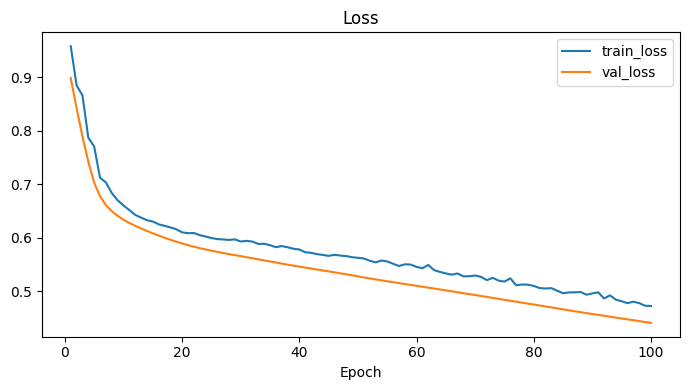

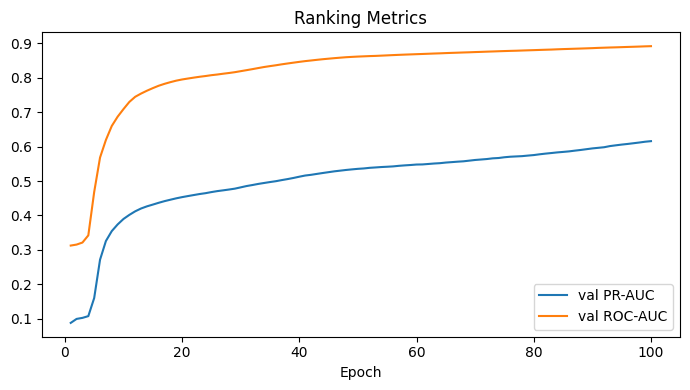

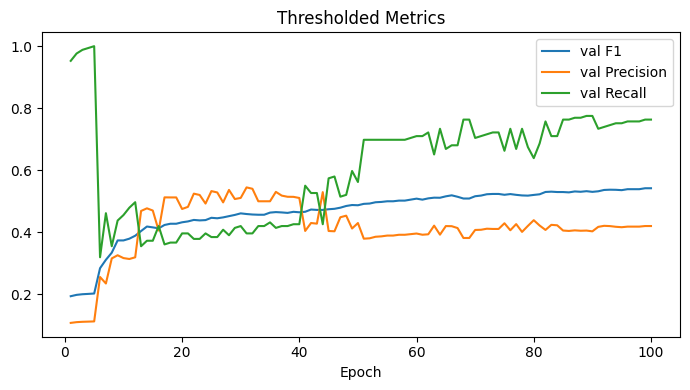

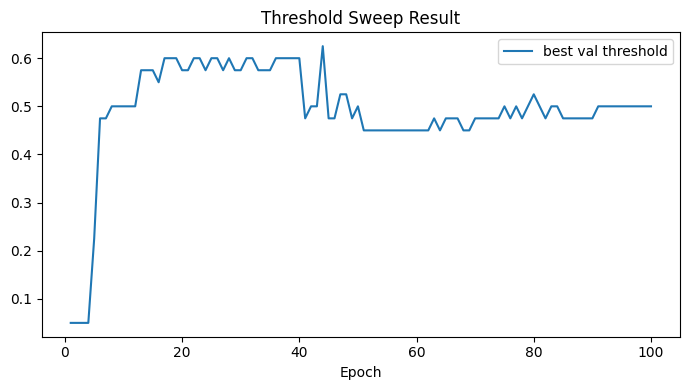

In [5]:
best_model, history_df = train_model(
    model=model,
    data=data,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    epochs=EPOCHS,
    patience=PATIENCE,
    threshold_objective=THRESHOLD_OBJECTIVE,
)

display(history_df.tail())
plot_training_history(history_df)


In [6]:
val_true, val_prob = predict_probabilities(best_model, data, "val_mask")
best_threshold = find_best_threshold(val_true, val_prob, objective=THRESHOLD_OBJECTIVE)

test_true, test_prob = predict_probabilities(best_model, data, "test_mask")
test_metrics = evaluate_probabilities(test_true, test_prob, best_threshold)

metrics_df = pd.DataFrame([test_metrics]).T.rename(columns={0: "value"})
display(metrics_df)


,value
Threshold,0.500000
PR-AUC,0.601542
ROC-AUC,0.877887
F1,0.517745
Precision,0.400000
Recall,0.733728
Specificity,0.860255
NPV,0.962185
Balanced-Accuracy,0.796992
MCC,0.463823


In [7]:
report_df = classification_report_df(test_true, test_prob, best_threshold)
display(report_df)


,precision,recall,f1-score,support
0,0.962185,0.860255,0.908370,1331.000
1,0.400000,0.733728,0.517745,169.000
accuracy,0.846000,0.846000,0.846000,0.846
macro avg,0.681092,0.796992,0.713057,1500.000
weighted avg,0.898845,0.846000,0.864359,1500.000


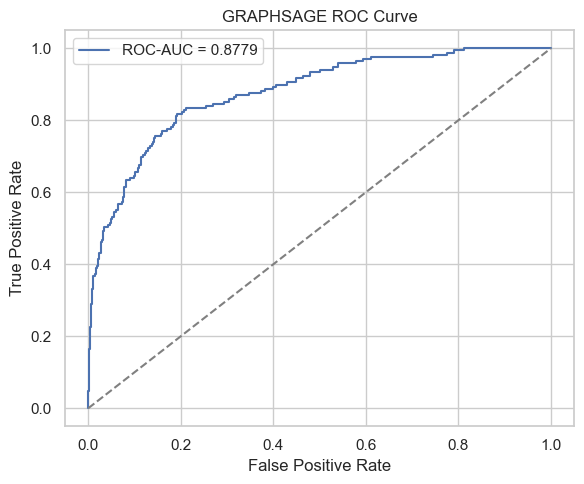

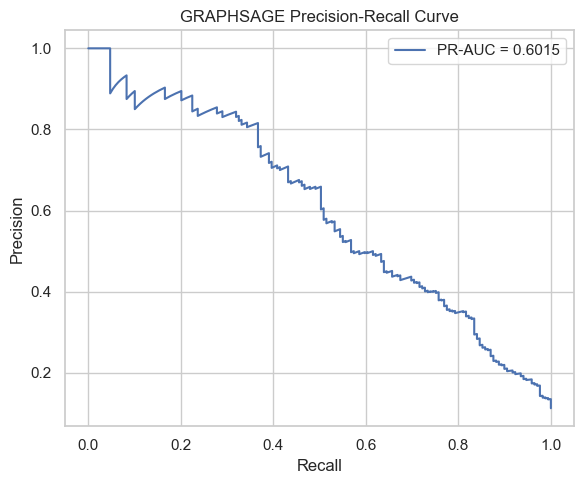

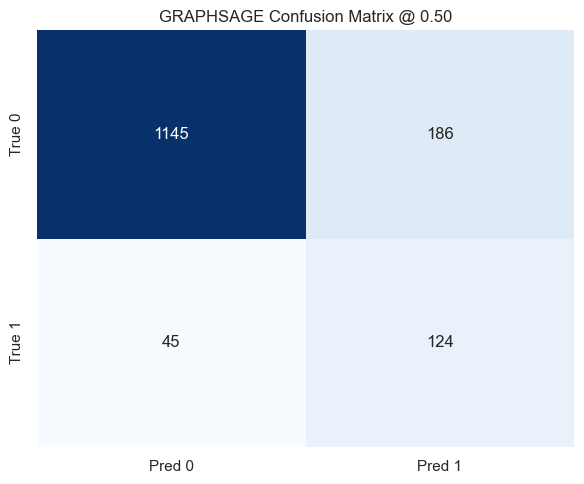

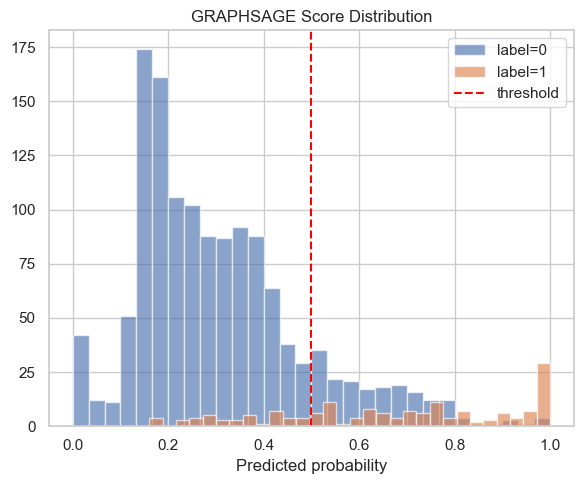

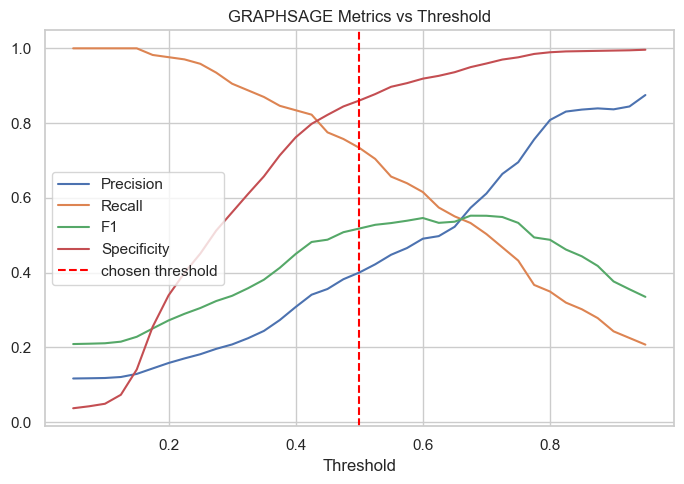

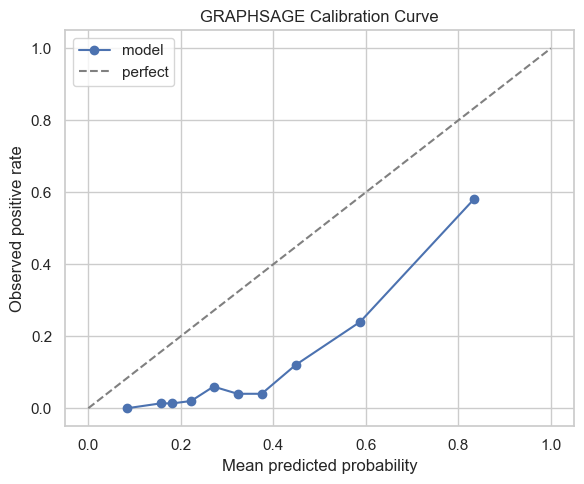

In [8]:
plot_evaluation_dashboard(
    y_true=test_true,
    y_prob=test_prob,
    threshold=best_threshold,
    title_prefix=MODEL_NAME.upper(),
)


In [ ]:
test_node_rows = data["nodes_df"].loc[data["test_mask"].detach().cpu().numpy()].copy()
test_node_rows["predicted_probability"] = test_prob
test_node_rows["predicted_label"] = (test_prob >= best_threshold).astype(int)

suspicious_wallets = test_node_rows.sort_values("predicted_probability", ascending=False).head(25)
display(
    suspicious_wallets[
        [
            "node_id",
            "label",
            "predicted_probability",
            "predicted_label",
            "full_total_degree",
            "sub_total_degree",
        ]
    ]
)


,node_id,label,predicted_probability,predicted_label,full_total_degree,sub_total_degree
1539,204115,1,1.000000,1,1,1
2209,276703,1,1.000000,1,1,0
2046,258361,1,1.000000,1,2,0
2478,308537,1,1.000000,1,1,1
2732,341302,1,0.999973,1,4,2
1834,235606,1,0.999973,1,5,5
1773,230116,1,0.999924,1,1,0
2754,343737,1,0.999797,1,2,1
2315,288808,0,0.999782,1,67,2
1807,233182,1,0.999505,1,1,1


: 

## Notes

Keep the reported `PR-AUC`, `Recall`, `Precision`, `F1`, `Balanced-Accuracy`, and `MCC` together when comparing models.
The threshold comes from validation data and is reused on the test split.
